<a href="https://colab.research.google.com/github/jegillis323/MAT-422/blob/main/MAT422_Section_2_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MAT422 - Section 2.4: MLE and Linear Regression
Topics: MLE for Random Samples and Linear Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)

#2.4.1 MLE for Random Samples

Number of Successes: 31
MLE p_hat: 0.62
Grid Search MLE: 0.6206532663316583


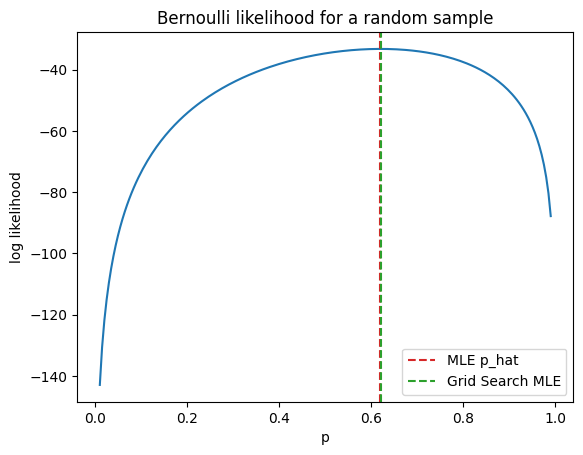

In [5]:
n = 50
true_p = 0.7
sample = rng.binomial(1, true_p, n)
p_hat = sample.mean()

grid = np.linspace(0.01, 0.99, 200)
log_likelihood = np.log(grid) * sample.sum() + np.log(1 - grid) * (n - sample.sum())
maximum_likelehood_index = np.argmax(log_likelihood)
grid_mle = grid[maximum_likelehood_index]

print("Number of Successes:", sample.sum())
print("MLE p_hat:", p_hat)
print("Grid Search MLE:", grid_mle)

plt.plot(grid, log_likelihood)
plt.axvline(p_hat, color="tab:red", linestyle="--", label="MLE p_hat")
plt.axvline(grid_mle, color="tab:green", linestyle="--", label="Grid Search MLE")
plt.xlabel("p")
plt.ylabel("log likelihood")
plt.title("Bernoulli likelihood for a random sample")
plt.legend()
plt.show()



My Explanation: Maximum Likelihood Estimation (MLE), is the process of finding the probability fitting some set of random data. We generated a set of points and use MLE to estimate the probability that this occurred. The sample mean gives the exact analyitical MLE for the set of data while the grid search MLE gives the best numerical approximation that we have of the collection of values we have in grid.

#2.4.2 Linear Regression

Estimated intercept and slope = [4.48103131 1.52861722]
True intercept and slope = 4 1.7
Residual sum of squares = 69.1688397211321


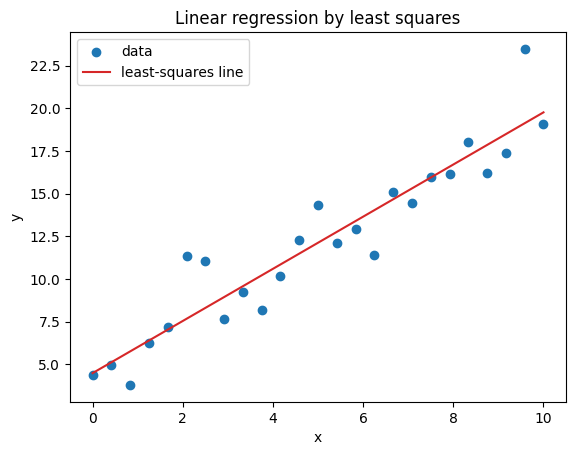

In [7]:
x = np.linspace(0, 10, 25)
y = 4 + 1.7 * x + rng.normal(0, 1.5, size=x.size)
X = np.column_stack([np.ones_like(x), x])
beta_hat = np.linalg.inv(X.T @ X) @ X.T @ y
y_hat = X @ beta_hat
residuals = y - y_hat

print("Estimated intercept and slope =", beta_hat)
print("True intercept and slope =", 4, 1.7)
print("Residual sum of squares =", np.sum(residuals ** 2))

plt.scatter(x, y, label="data")
plt.plot(x, y_hat, color="tab:red", label="least-squares line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear regression by least squares")
plt.legend()
plt.show()

My Explanation: The data starts with the line $y = 4 + 1.7x + \epsilon$ where $\epsilon \sim N(0, 1.5^2)$, which fits the probabilitic description of regression, an observed $y_i$ is its predicted values with some random error $y_i = \hat{y}_i + \epsilon$ that is normally distributed. We construct a matrix of the values of $x$ that were generated which estimate the slope and the intercept of the line.